# ... 3 ...

# Offloading a flow

In [7]:
from cosim import Flow, Infra, Kio, Cost, Solutions
from db import Flowdb, Infradb
import random

### Requires infra

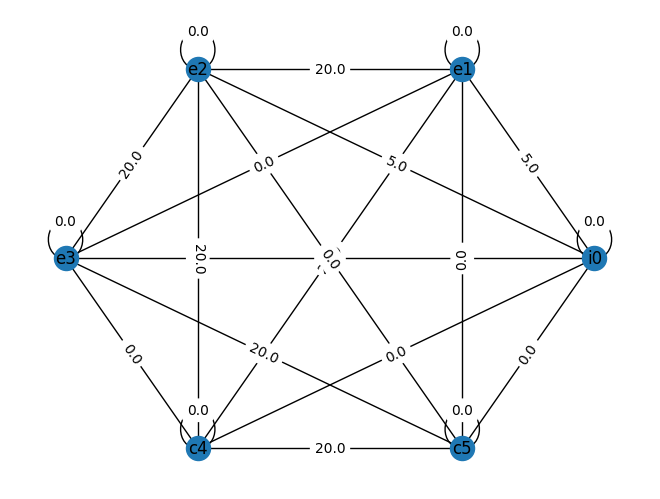

Node i0:{'rate': 5.0}
Node e1:{'rate': 2.0}
Node e2:{'rate': 2.0}
Node e3:{'rate': 2.0}
Node c4:{'rate': 1.0}
Node c5:{'rate': 1.0}
Edge ('i0', 'i0'):{'rate': 0.0}
Edge ('i0', 'e1'):{'rate': 5.0}
Edge ('i0', 'e2'):{'rate': 5.0}
Edge ('i0', 'e3'):{'rate': 5.0}
Edge ('i0', 'c4'):{'rate': 0.0}
Edge ('i0', 'c5'):{'rate': 0.0}
Edge ('e1', 'e1'):{'rate': 0.0}
Edge ('e1', 'e2'):{'rate': 20.0}
Edge ('e1', 'e3'):{'rate': 0.0}
Edge ('e1', 'c4'):{'rate': 20.0}
Edge ('e1', 'c5'):{'rate': 0.0}
Edge ('e2', 'e2'):{'rate': 0.0}
Edge ('e2', 'e3'):{'rate': 20.0}
Edge ('e2', 'c4'):{'rate': 20.0}
Edge ('e2', 'c5'):{'rate': 0.0}
Edge ('e3', 'e3'):{'rate': 0.0}
Edge ('e3', 'c4'):{'rate': 0.0}
Edge ('e3', 'c5'):{'rate': 20.0}
Edge ('c4', 'c4'):{'rate': 0.0}
Edge ('c4', 'c5'):{'rate': 20.0}
Edge ('c5', 'c5'):{'rate': 0.0}


In [8]:
infra_name = 'infra_2'
infra = Infra(Infradb.Get(infra_name))
infra.render()
print(infra)

### Requires infra instance (randomization)

In [9]:

infra = infra * [random.randint(5, 19)/10 for _ in infra.nodes] # set task rates
infra = infra / [random.randint(15, 99)/100 for _ in infra.edges] # set data rates
print(infra)

Node i0:{'rate': 1.7}
Node e1:{'rate': 1.4}
Node e2:{'rate': 0.5}
Node e3:{'rate': 1.2}
Node c4:{'rate': 0.6}
Node c5:{'rate': 0.7}
Edge ('i0', 'i0'):{'rate': 0.79}
Edge ('i0', 'e1'):{'rate': 0.38}
Edge ('i0', 'e2'):{'rate': 0.87}
Edge ('i0', 'e3'):{'rate': 0.77}
Edge ('i0', 'c4'):{'rate': 0.9}
Edge ('i0', 'c5'):{'rate': 0.52}
Edge ('e1', 'e1'):{'rate': 0.47}
Edge ('e1', 'e2'):{'rate': 0.84}
Edge ('e1', 'e3'):{'rate': 0.21}
Edge ('e1', 'c4'):{'rate': 0.8}
Edge ('e1', 'c5'):{'rate': 0.19}
Edge ('e2', 'e2'):{'rate': 0.99}
Edge ('e2', 'e3'):{'rate': 0.18}
Edge ('e2', 'c4'):{'rate': 0.28}
Edge ('e2', 'c5'):{'rate': 0.92}
Edge ('e3', 'e3'):{'rate': 0.15}
Edge ('e3', 'c4'):{'rate': 0.48}
Edge ('e3', 'c5'):{'rate': 0.44}
Edge ('c4', 'c4'):{'rate': 0.54}
Edge ('c4', 'c5'):{'rate': 0.51}
Edge ('c5', 'c5'):{'rate': 0.16}


### Requires flow

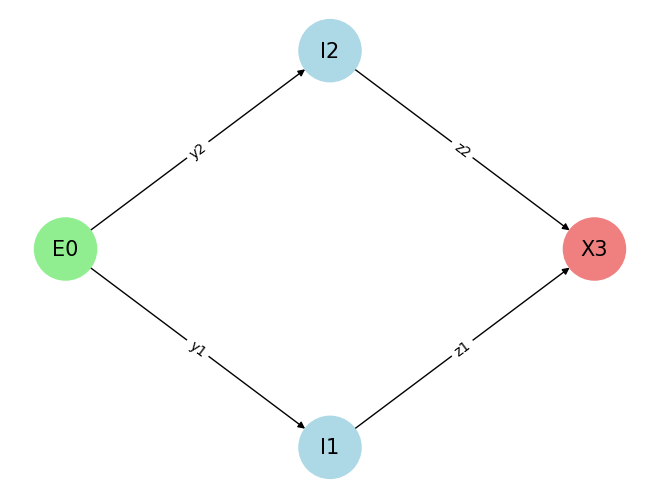

Node E0:{'inputs': ('x',), 'outputs': ('y1', 'y2'), 'size': 0.0, 'decision': None, 'subset': 0}
Node I1:{'inputs': ('y1',), 'outputs': ('z1',), 'size': 0.0, 'decision': None, 'subset': 1}
Node I2:{'inputs': ('y2',), 'outputs': ('z2',), 'size': 0.0, 'decision': None, 'subset': 1}
Node X3:{'inputs': ('z1', 'z2'), 'outputs': ('o',), 'size': 0.0, 'decision': None, 'subset': 2}
Edge ('E0', 'I1'):{'data': 'y1', 'size': 0.0}
Edge ('E0', 'I2'):{'data': 'y2', 'size': 0.0}
Edge ('I1', 'X3'):{'data': 'z1', 'size': 0.0}
Edge ('I2', 'X3'):{'data': 'z2', 'size': 0.0}


In [10]:
flow_name = 'flow_2'
flow = Flow(flow_name, Flowdb.Get(flow_name))
flow.render(drawargs=dict(font_size=15, node_size=2000), edge_labels=True, layout='multipartite_layout', )
print(flow)

### Requires flow instance

In [11]:

flow = flow * [random.randint(5, 19) for _ in flow.nodes] # set task sizes
flow = flow / [random.randint(15, 99) for _ in flow.edges] # set data sizes
print(flow)

Node E0:{'inputs': ('x',), 'outputs': ('y1', 'y2'), 'size': 14.0, 'decision': None, 'subset': 0}
Node I1:{'inputs': ('y1',), 'outputs': ('z1',), 'size': 18.0, 'decision': None, 'subset': 1}
Node I2:{'inputs': ('y2',), 'outputs': ('z2',), 'size': 9.0, 'decision': None, 'subset': 1}
Node X3:{'inputs': ('z1', 'z2'), 'outputs': ('o',), 'size': 16.0, 'decision': None, 'subset': 2}
Edge ('E0', 'I1'):{'data': 'y1', 'size': 25.0}
Edge ('E0', 'I2'):{'data': 'y2', 'size': 71.0}
Edge ('I1', 'X3'):{'data': 'z1', 'size': 42.0}
Edge ('I2', 'X3'):{'data': 'z2', 'size': 46.0}


### Define decision policy

In [12]:
decision = Solutions.Random(flow, infra)
print(decision)

decision = Solutions.Random(flow, infra, fixl=1)
print(decision)

decision = Solutions.Random(flow, infra, fixl=1, fixi=1)
print(decision)

decision = Solutions.Random(flow, infra, fixl=1, fixr=1, fixi=2)
print(decision)

['i0', 'c5', 'c5', 'e2']
['i0', 'i0', 'e2', 'e3']
['e1', 'e2', 'e3', 'c5']
['e2', 'c5', 'c5', 'e2']


In [13]:
decision = Solutions.Fixed(0, flow, infra)
print(decision)

decision = Solutions.Fixed(2, flow, infra, fixl=1)
print(decision)

decision = Solutions.Fixed(1, flow, infra, fixl=1, fixi=2)
print(decision)

decision = Solutions.Fixed(1, flow, infra, fixl=1, fixr=1, fixi=0)
print(decision)


['i0', 'i0', 'i0', 'i0']
['i0', 'e2', 'e2', 'e2']
['e2', 'e1', 'e1', 'e1']
['i0', 'e1', 'e1', 'i0']


In [14]:
total_sols = Solutions.Count(flow, infra, fix=2)
total_sols

36

In [15]:
decision = Solutions.Solution(34, flow, infra, fixl=1, fixr=1, fixi=0)
print(decision)

['i0', 'c4', 'c5', 'i0']


### Requires decision

In [16]:
flow = flow + decision # set decision
cost, path = Cost(flow, infra)
print(cost, path)
print(flow)

122.1 ['E0', 'I1', 'X3']
Node E0:{'inputs': ('x',), 'outputs': ('y1', 'y2'), 'size': 14.0, 'decision': 'i0', 'subset': 0, 'delay': 23.8}
Node I1:{'inputs': ('y1',), 'outputs': ('z1',), 'size': 18.0, 'decision': 'c4', 'subset': 1, 'delay': 10.799999999999999}
Node I2:{'inputs': ('y2',), 'outputs': ('z2',), 'size': 9.0, 'decision': 'c5', 'subset': 1, 'delay': 6.3}
Node X3:{'inputs': ('z1', 'z2'), 'outputs': ('o',), 'size': 16.0, 'decision': 'i0', 'subset': 2, 'delay': 27.2}
Edge ('E0', 'I1'):{'data': 'y1', 'size': 25.0, 'delay': 22.5, 'weight': -46.3}
Edge ('E0', 'I2'):{'data': 'y2', 'size': 71.0, 'delay': 36.92, 'weight': -60.72}
Edge ('I1', 'X3'):{'data': 'z1', 'size': 42.0, 'delay': 37.800000000000004, 'weight': -75.8}
Edge ('I2', 'X3'):{'data': 'z2', 'size': 46.0, 'delay': 23.92, 'weight': -57.42}


In [17]:
if total_sols>10000: raise StopAsyncIteration('Too many Solutions')

## Feasible

In [18]:
sols = Solutions.Enumerate(flow, infra, fixl=1, fixr=1, fixi=0)

y = []
for i,s in enumerate(sols):
    flow = flow + s # set decision
    cost, path = Cost(flow, infra)
    y.append(cost)
    print(s, cost, path)

x = list(range(len(sols)))


['i0', 'i0', 'i0', 'i0'] 158.73000000000002 ['E0', 'I2', 'X3']
['i0', 'e1', 'i0', 'i0'] 158.73000000000002 ['E0', 'I2', 'X3']
['i0', 'e2', 'i0', 'i0'] 158.73000000000002 ['E0', 'I2', 'X3']
['i0', 'e3', 'i0', 'i0'] 158.73000000000002 ['E0', 'I2', 'X3']
['i0', 'c4', 'i0', 'i0'] 158.73000000000002 ['E0', 'I2', 'X3']
['i0', 'c5', 'i0', 'i0'] 158.73000000000002 ['E0', 'I2', 'X3']
['i0', 'i0', 'e1', 'i0'] 134.53 ['E0', 'I1', 'X3']
['i0', 'e1', 'e1', 'i0'] 108.06 ['E0', 'I2', 'X3']
['i0', 'e2', 'e1', 'i0'] 118.28999999999999 ['E0', 'I1', 'X3']
['i0', 'e3', 'e1', 'i0'] 124.19 ['E0', 'I1', 'X3']
['i0', 'c4', 'e1', 'i0'] 122.1 ['E0', 'I1', 'X3']
['i0', 'c5', 'e1', 'i0'] 108.06 ['E0', 'I2', 'X3']
['i0', 'i0', 'e2', 'i0'] 157.29000000000002 ['E0', 'I2', 'X3']
['i0', 'e1', 'e2', 'i0'] 157.29000000000002 ['E0', 'I2', 'X3']
['i0', 'e2', 'e2', 'i0'] 157.29000000000002 ['E0', 'I2', 'X3']
['i0', 'e3', 'e2', 'i0'] 157.29000000000002 ['E0', 'I2', 'X3']
['i0', 'c4', 'e2', 'i0'] 157.29000000000002 ['E0', 'I

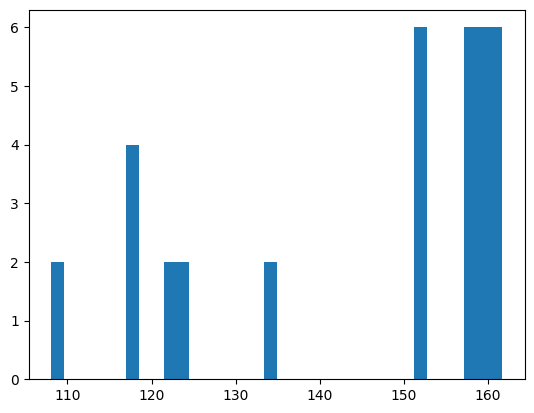

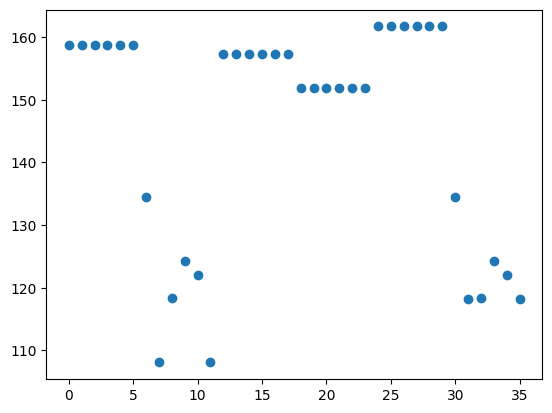

Min Cost: 108.06 (2 of 36, Prob = 0.05555555555555555)
Avg Cost: 145.22999999999996
Max Cost: 161.7 (6 of 36, Prob = 0.16666666666666666)
['i0', 'e1', 'e1', 'i0'] 108.06
['i0', 'c5', 'e1', 'i0'] 108.06
['i0', 'e1', 'c5', 'i0'] 118.14
['i0', 'c5', 'c5', 'i0'] 118.14
['i0', 'e2', 'c5', 'i0'] 118.28999999999999
['i0', 'e2', 'e1', 'i0'] 118.28999999999999
['i0', 'c4', 'e1', 'i0'] 122.1
['i0', 'c4', 'c5', 'i0'] 122.1
['i0', 'e3', 'c5', 'i0'] 124.19
['i0', 'e3', 'e1', 'i0'] 124.19
['i0', 'i0', 'c5', 'i0'] 134.53
['i0', 'i0', 'e1', 'i0'] 134.53
['i0', 'e2', 'e3', 'i0'] 151.89
['i0', 'e3', 'e3', 'i0'] 151.89
['i0', 'c5', 'e3', 'i0'] 151.89
['i0', 'c4', 'e3', 'i0'] 151.89
['i0', 'i0', 'e3', 'i0'] 151.89
['i0', 'e1', 'e3', 'i0'] 151.89
['i0', 'e3', 'e2', 'i0'] 157.29000000000002
['i0', 'e2', 'e2', 'i0'] 157.29000000000002
['i0', 'c5', 'e2', 'i0'] 157.29000000000002
['i0', 'c4', 'e2', 'i0'] 157.29000000000002
['i0', 'e1', 'e2', 'i0'] 157.29000000000002
['i0', 'i0', 'e2', 'i0'] 157.29000000000002


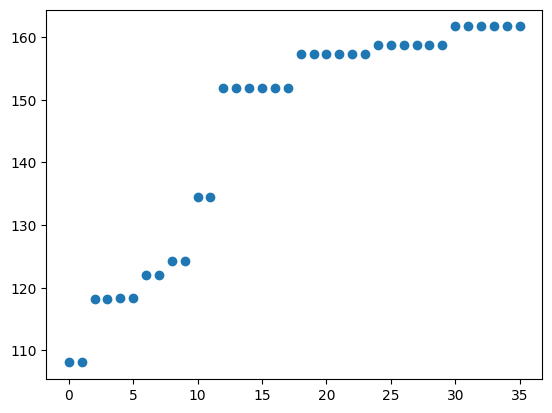

In [19]:
import numpy as np

import matplotlib.pyplot as plt

plt.hist(y, bins=len(sols))
plt.show()
plt.scatter(x,y)
plt.show()


yy = np.array(y)
yi = np.argsort(yy)
xx = [sols[i] for i in yi]
yy = yy[yi]

miny = yy[0]
maxy = yy[-1]
meany = np.mean(yy)

min_count = len(np.where((yy==miny))[0])
max_count = len(np.where((yy==maxy))[0])
min_prob = min_count/total_sols
max_prob = max_count/total_sols

print(f'Min Cost: {miny} ({min_count} of {total_sols}, Prob = {min_prob})')
print(f'Avg Cost: {meany}')
print(f'Max Cost: {maxy} ({max_count} of {total_sols}, Prob = {max_prob})')


for i,j in zip(xx, yy):
    print(i,j)
plt.scatter(x,yy)




